## Glucose Metabolism

Obesity is often positively correlated with diabetes and insulin resistance. This analysis will be focusing on the glucose metabolic markers in the blood work.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
from math import erf, sqrt
from math import atanh, sqrt

In [3]:
df_a = pd.read_csv('cleaned_anthropometry.csv')
df_d = pd.read_csv('cleaned_demographics.csv')
df_h = pd.read_csv('clean_hgba1c.csv')
df_i = pd.read_csv('clean_insulin.csv')
df_fg = pd.read_csv('clean_fasting_glu.csv')

### Hemoglobin A1c

Hemoglobin A1c is often used to assess whether someone has diabetes. It takes an average of the glucose saturation in the hemoglobin in the past 3 months from the time the test is performed. It is measured in percentages. 

The known range of the values are as follows:

* Normal: <5.7%
* Prediabetes: 5.7-6.4%
* Diabetes: >6.5%

In [4]:
df_a.head()

,participant_id,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,arm_circumference_cm,waist_circ_cm,hip_circ_cm
0,109264.0,42.2,NaN,NaN,154.7,NaN,17.6,2.0,36.3,33.8,22.7,63.8,85.0
1,109265.0,12.0,NaN,91.6,89.3,NaN,15.0,2.0,NaN,18.6,14.8,41.2,NaN
2,109266.0,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
3,109269.0,13.6,NaN,90.9,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109270.0,75.3,NaN,NaN,156.0,NaN,30.9,4.0,42.6,36.1,31.0,91.4,NaN


In [6]:
df_a.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'],
      dtype='object')

In [8]:
df_a = df_a.drop(['weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment',  'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm'], axis = 1)

In [9]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [10]:
df_d.columns

Index(['participant_id', 'gender', 'age_year', 'race', 'education_level',
       'marital_status', 'family_income_poverty'],
      dtype='object')

In [12]:
df_d = df_d.drop(['race', 'education_level',
       'marital_status', 'family_income_poverty'], axis=1)

In [19]:
df = df_a.merge(df_d, on = 'participant_id')

In [20]:
df.head()

,participant_id,bmi,gender,age_year
0,109264.0,17.6,2.0,13.0
1,109265.0,15.0,1.0,2.0
2,109266.0,37.8,2.0,29.0
3,109269.0,NaN,1.0,2.0
4,109270.0,30.9,2.0,11.0


In [25]:
df_hgb = df.merge(df_h, on='participant_id')

In [26]:
df_hgb.head()

,participant_id,bmi,gender,age_year,Unnamed: 0,glycohemoglobin_percent
0,109264.0,17.6,2.0,13.0,0,5.3
1,109266.0,37.8,2.0,29.0,1,5.2
2,109271.0,29.7,1.0,49.0,2,5.6
3,109273.0,21.9,1.0,36.0,3,5.1
4,109274.0,30.2,1.0,68.0,4,5.7


In [27]:
df_hgb = df_hgb.drop('Unnamed: 0', axis=1)

In [28]:
df_hgb.describe()

,participant_id,bmi,gender,age_year,glycohemoglobin_percent
count,9618.000000,9580.000000,9618.000000,9618.000000,9618.000000
mean,117093.156373,29.160031,1.510085,44.971200,5.765700
std,4494.854416,7.622358,0.499924,20.785973,1.067351
min,109264.000000,13.200000,1.000000,12.000000,2.800000
25%,113211.500000,23.900000,1.000000,26.000000,5.200000
50%,117090.500000,28.000000,2.000000,46.000000,5.500000
75%,120998.250000,33.100000,2.000000,62.000000,5.900000
max,124822.000000,92.300000,2.000000,80.000000,16.200000


The average HgbA1c level is 5.7%, which is right at the start of the prediabetes range. Considering the general population is 70% overweight or obese, the average is understandable. The maximum value of the A1c is 16, which is definitely a possibility but not seen as frequently. 

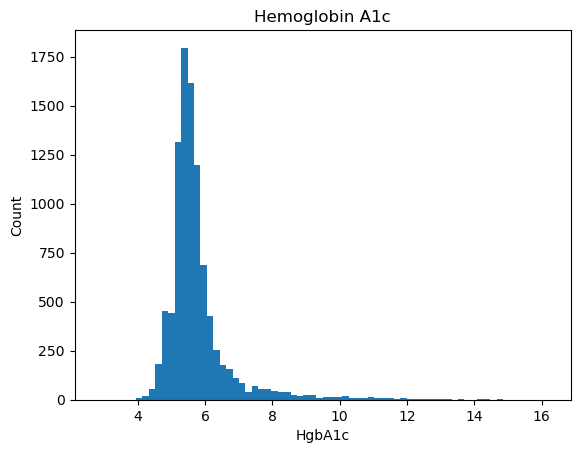

In [31]:
plt.hist(df_hgb['glycohemoglobin_percent'], bins=70)
plt.title("Hemoglobin A1c")
plt.xlabel("HgbA1c")
plt.ylabel("Count")
plt.show()

The histogram of the A1c values shows right skewness to the data. It appears that there are not many people who fall in the range beyond 10%. 

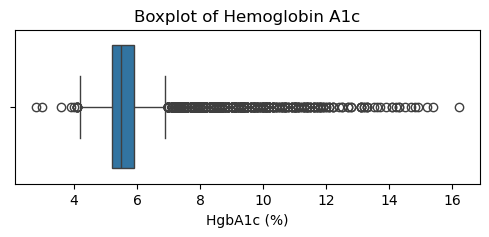

In [32]:
plt.figure(figsize=(6,2))
sns.boxplot(x=df_hgb['glycohemoglobin_percent'])
plt.title("Boxplot of Hemoglobin A1c")
plt.xlabel("HgbA1c (%)")
plt.show()